##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
pip install keras_cv

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 897.7 kB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 1.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 637.9 kB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 704.2 kB/s  0:00:49m0:00:0100:02
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21582 sha256=106cf07a4265f1e776f3dbf1b95c1b38c3624d6fca98ece03afefcfb1146fbf2
  Stored in directory: /Users/ykalsuhaili/Library/Caches/pip/wheels/e7/e6/28/864bdfee5339dbd6ddcb5a186286a8e217648ec198bdf0097d
Successfully built promise
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [keras_cv]/17 [keras_cv]w-datasets]otos]
Note: you may need to restart the kernel to use updated packages.


In [3]:
# imports
import keras_cv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

/opt/anaconda3/envs/cv_lab1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# load pretrained yolov8 model using pascal voc preset
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

100%|██████████| 2.27k/2.27k [00:00<00:00, 1.86MB/s]


100%|██████████| 99.5M/99.5M [00:28<00:00, 3.64MB/s]


In [5]:
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

In [6]:
# load 5 images for different classes
image_files = [
    "bird.jpg",
    "bottle.jpg",
    "car.jpg",
    "cat.jpg",
    "dog.jpg"
]

In [7]:
# load into numpy arrays
images = []

for file in image_files:
    img = Image.open(file).convert("RGB")
    img = np.array(img)
    images.append(img)

In [8]:
resized_images = []

for img in images:
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    resized = inference_resizing(img_tensor)
    resized_images.append(resized)

resized_images = tf.stack(resized_images)
print(resized_images.shape)

(5, 640, 640, 3)


In [9]:
# running the yolov8 detection
predictions = model.predict(resized_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
# class mapping
class_mapping = {
    0: "aeroplane",
    1: "bicycle",
    2: "bird",
    3: "boat",
    4: "bottle",
    5: "bus",
    6: "car",
    7: "cat",
    8: "chair",
    9: "cow",
    10: "diningtable",
    11: "dog",
    12: "horse",
    13: "motorbike",
    14: "person",
    15: "pottedplant",
    16: "sheep",
    17: "sofa",
    18: "train",
    19: "tvmonitor",
}

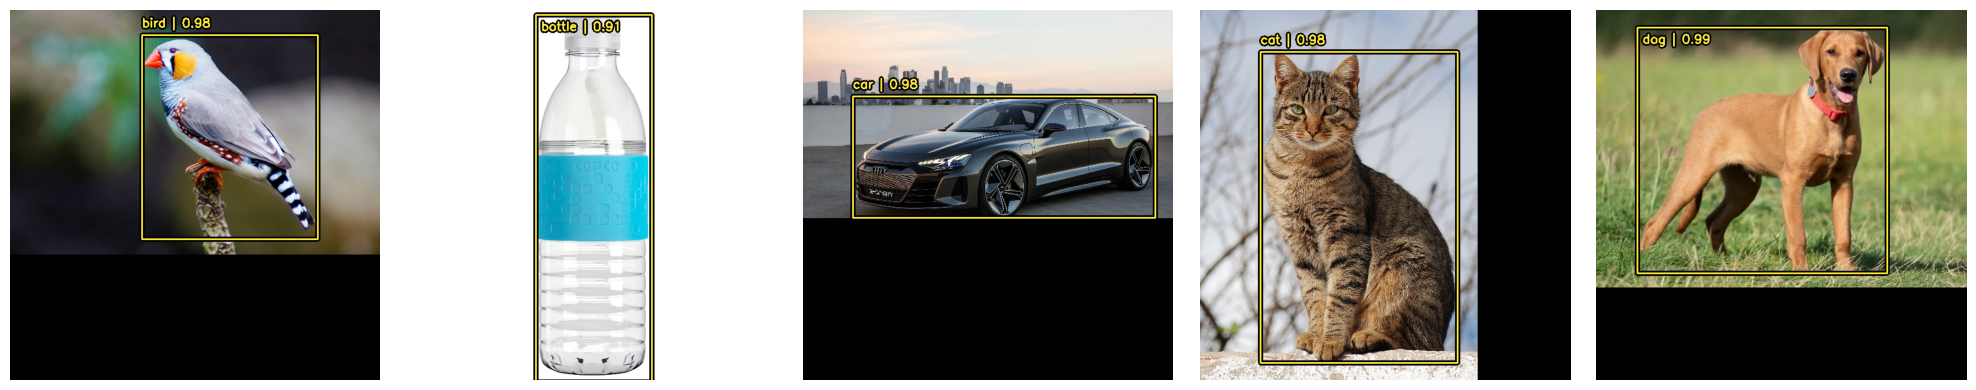

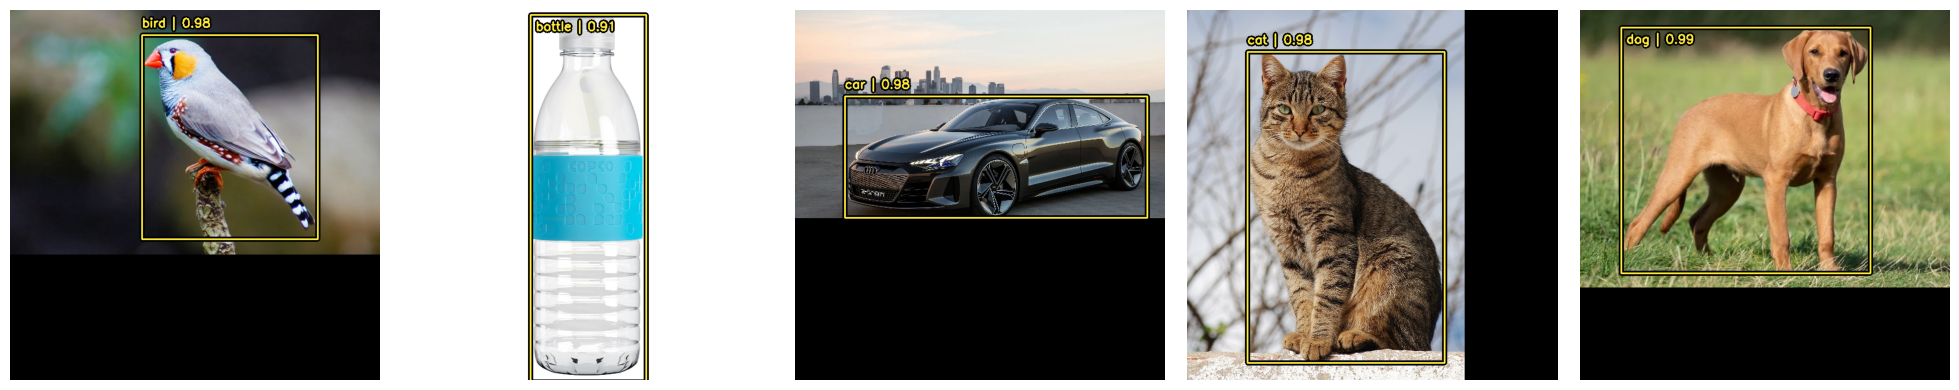

In [13]:
keras_cv.visualization.plot_bounding_box_gallery(
    resized_images,
    value_range=(0, 255),
    rows=1,
    cols=5,
    y_pred=predictions,
    scale=4,
    font_scale=0.7,
    bounding_box_format="xywh",
    class_mapping=class_mapping,
)

# Record Results 

| image file | detected object | confidence score | correct? | missed / incorrect |
| ---------- | --------------- | ---------------- | -------- | ------------------ |
| bird.jpg   | bird            | 0.98             | yes      | none               |
| bottle.jpg | bottle          | 0.91             | yes      | none               |
| car.jpg    | car             | 0.98             | yes      | none               |
| cat.jpg    | cat             | 0.98             | yes      | none               |
| dog.jpg    | dog             | 0.99             | yes      | none               |
